# MODIS Calibration Analysis with Time Series Visualization


In [1]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import our custom utilities
from modis_calibration_utils import (
    calibrate_with_outlier_detection,
    apply_calibration,
    create_outlier_comparison_plot,
    create_time_series_plot,
    combine_modis_sensors,
    match_satellite_insitu,
    export_calibrated_data,
    load_detroit_ysi_data
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
print("Enhanced MODIS Calibration Analysis - Libraries loaded successfully!")

Enhanced MODIS Calibration Analysis - Libraries loaded successfully!


## 1. Load UKL in situ data using existing function

In [ ]:
try:
    from load_ukl_data import load_ukl_insitu_data, filter_ukl_data_for_satellite_calibration
    
    # Load in situ UKL data using existing function
    raw_ukl_data = load_ukl_insitu_data()
    if len(raw_ukl_data) == 0:
        raise Exception("No UKL data loaded")
    
    # Filter for satellite calibration
    ukl_insitu = filter_ukl_data_for_satellite_calibration(raw_ukl_data, min_chl=1.0, max_chl=350.0)
    
    # Ensure proper column names
    if 'datetime' not in ukl_insitu.columns and 'date' in ukl_insitu.columns:
        ukl_insitu['datetime'] = pd.to_datetime(ukl_insitu['date'])
    
    print(f"In situ UKL data loaded: {len(ukl_insitu)} records")
    print(f"Date range: {ukl_insitu['datetime'].min()} to {ukl_insitu['datetime'].max()}")
    print(f"Chlorophyll range: {ukl_insitu['chlorophyll_ugL'].min():.1f} - {ukl_insitu['chlorophyll_ugL'].max():.1f} µg/L")
    
except Exception as e:
    print(f"Could not load UKL data using load_ukl_data.py: {e}")
    print("Falling back to CSV file loading...")
    
    # Fallback to direct CSV loading
    try:
        ukl_csv_path = 'UKL_insitu_chlorophyll.csv'
        raw_data = pd.read_csv(ukl_csv_path)
        raw_data['datetime'] = pd.to_datetime(raw_data['date'], errors='coerce')
        raw_data = raw_data.dropna(subset=['datetime', 'chlorophyll_ugL'])
        
        # Filter for satellite calibration
        ukl_insitu = raw_data[
            (raw_data['chlorophyll_ugL'] >= 1.0) & 
            (raw_data['chlorophyll_ugL'] <= 350.0)
        ].copy()
        
        print(f"UKL data loaded from CSV: {len(ukl_insitu)} records")
        
    except Exception as e2:
        print(f"Error loading UKL data from CSV: {e2}")
        ukl_insitu = None

# Load Detroit YSI data
print("\nLoading Detroit YSI data...")
detroit_insitu = load_detroit_ysi_data()

Loading UKL in situ data from: /Users/todd/GitHub/ecohydrology/CE-QUAL-W2-HAB-Capabilities/Data/Upper_Klamath_Lake/Klamath K.csv
Found 1486 chlorophyll measurements

Data Summary:
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 0.8 - 1341.3 µg/L
Mean chlorophyll: 57.5 µg/L
Median chlorophyll: 23.9 µg/L
Organizations: ['CEDEN' 'KLAMATHTRIBES_WQX']
Number of unique locations: 22
Filtering results:
  Initial records: 1486
  Final records: 1469
  Removed: 17 (1.1%)
Real UKL data loaded: 1469 records
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 1.6 - 344.4 µg/L

Loading Detroit YSI data...
Detroit YSI data loaded: 7029 measurements
Date range: 2010-06-29 10:21:00 to 2022-09-06 11:15:53
Chlorophyll range: 0.0 - 17.4 µg/L


## 2. Load MODIS Satellite Data

In [3]:
# Load MODIS satellite data
def load_modis_data(file_paths):
    """
    Load MODIS data from multiple files
    
    Args:
        file_paths: Dictionary with sensor names as keys and file paths as values
    """
    modis_data = {}
    
    for sensor_name, file_path in file_paths.items():
        try:
            df = pd.read_csv(file_path)
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            df = df.dropna(subset=['datetime'])
            df = df.sort_values('datetime').reset_index(drop=True)
            
            # Add sensor label
            df['sensor'] = sensor_name
            
            modis_data[sensor_name] = df
            print(f"{sensor_name}: {len(df)} records")
            
        except Exception as e:
            print(f"Error loading {sensor_name} data: {e}")
            modis_data[sensor_name] = None
    
    return modis_data

# Define file paths - UPDATE THESE TO MATCH YOUR FILE STRUCTURE
ukl_files = {
    'UKL-Terra': 'UKL_MODIS_Multiband_Terra.csv',
    'UKL-Aqua': 'UKL_MODIS_Multiband_Aqua.csv'
}

detroit_files = {
    'Detroit-Terra': 'Detroit_Mid-Lake_MODIS_Multiband_Terra.csv',
    'Detroit-Aqua': 'Detroit_Mid-Lake_MODIS_Multiband_Aqua.csv'
}

print("Loading UKL MODIS data for calibration:")
ukl_modis = load_modis_data(ukl_files)

print("\nLoading Detroit MODIS data for application:")
detroit_modis = load_modis_data(detroit_files)

Loading UKL MODIS data for calibration:
UKL-Terra: 2497 records
UKL-Aqua: 2395 records

Loading Detroit MODIS data for application:
Error loading Detroit-Terra data: [Errno 2] No such file or directory: 'Detroit_Mid-Lake_MODIS_Multiband_Terra.csv'
Error loading Detroit-Aqua data: [Errno 2] No such file or directory: 'Detroit_Mid-Lake_MODIS_Multiband_Aqua.csv'


## 3. Band Ratio Analysis and Calibration

In [4]:
# Analyze different band combinations
def analyze_band_ratios(modis_data, lake_name):
    """Analyze spectral band ratios for a lake"""
    print(f"\n=== {lake_name} Band Ratio Analysis ===")
    
    all_data = []
    for sensor_name, df in modis_data.items():
        if df is not None and len(df) > 0:
            all_data.append(df)
    
    if not all_data:
        print("No data available for analysis")
        return None
    
    # Combine all sensor data
    combined = pd.concat(all_data, ignore_index=True)
    
    # Calculate band ratios
    combined['green_red_ratio'] = combined['band4_green'] / combined['band1_red']
    combined['nir_red_ratio'] = combined['band2_nir'] / combined['band1_red']
    combined['log_green_red'] = np.log10(combined['green_red_ratio'])
    combined['log_nir_red'] = np.log10(combined['nir_red_ratio'])
    
    # Statistics
    print(f"Green/Red ratio: {combined['green_red_ratio'].mean():.3f} ± {combined['green_red_ratio'].std():.3f}")
    print(f"NIR/Red ratio: {combined['nir_red_ratio'].mean():.3f} ± {combined['nir_red_ratio'].std():.3f}")
    print(f"Log Green/Red: {combined['log_green_red'].mean():.3f} ± {combined['log_green_red'].std():.3f}")
    print(f"Log NIR/Red: {combined['log_nir_red'].mean():.3f} ± {combined['log_nir_red'].std():.3f}")
    
    return combined

# Analyze band ratios
ukl_analysis = analyze_band_ratios(ukl_modis, "Upper Klamath Lake")
detroit_analysis = analyze_band_ratios(detroit_modis, "Detroit Lake")


=== Upper Klamath Lake Band Ratio Analysis ===
Green/Red ratio: 1.485 ± 2.420
NIR/Red ratio: 0.643 ± 2.299
Log Green/Red: 0.138 ± 0.123
Log NIR/Red: -0.360 ± 0.319

=== Detroit Lake Band Ratio Analysis ===
No data available for analysis


## 4. Calibration with Outlier Detection

In [5]:
# Match UKL MODIS with in situ data for calibration
print("Matching UKL satellite data with in situ measurements...")

all_ukl_matches = []

for sensor_name, modis_df in ukl_modis.items():
    if modis_df is not None and len(modis_df) > 0:
        # Try different band ratio columns that might exist
        possible_cols = ['log_green_red', 'green_red_ratio', 'log_nir_red', 'nir_red_ratio']
        
        for col in possible_cols:
            if col in modis_df.columns:
                matches = match_satellite_insitu(modis_df, ukl_insitu, col, temporal_window_hours=6)
                if len(matches) > 0:
                    matches['sensor_name'] = sensor_name
                    matches['band_ratio_type'] = col
                    all_ukl_matches.append(matches)
                print(f"{sensor_name} - {col}: {len(matches)} matches")
                break

if all_ukl_matches:
    ukl_matched_data = pd.concat(all_ukl_matches, ignore_index=True)
    print(f"\nTotal matched pairs: {len(ukl_matched_data)}")
else:
    print("No matches found - check data compatibility")

Matching UKL satellite data with in situ measurements...
UKL-Terra - green_red_ratio: 878 matches
UKL-Aqua - green_red_ratio: 905 matches

Total matched pairs: 1783



CALIBRATING GREEN_RED_RATIO METHOD

Calibrating UKL-green_red_ratio...
Initial clean matches: 1783
Outliers detected: 28
Data points after outlier removal: 1755
Calibration results for UKL-green_red_ratio:
  Original data: 1783 matches, R² = 0.317, RMSE = 0.402
  Cleaned data: 1755 matches, R² = 0.349, RMSE = 0.388
  - Slope: 1.091
  - Intercept: -0.029


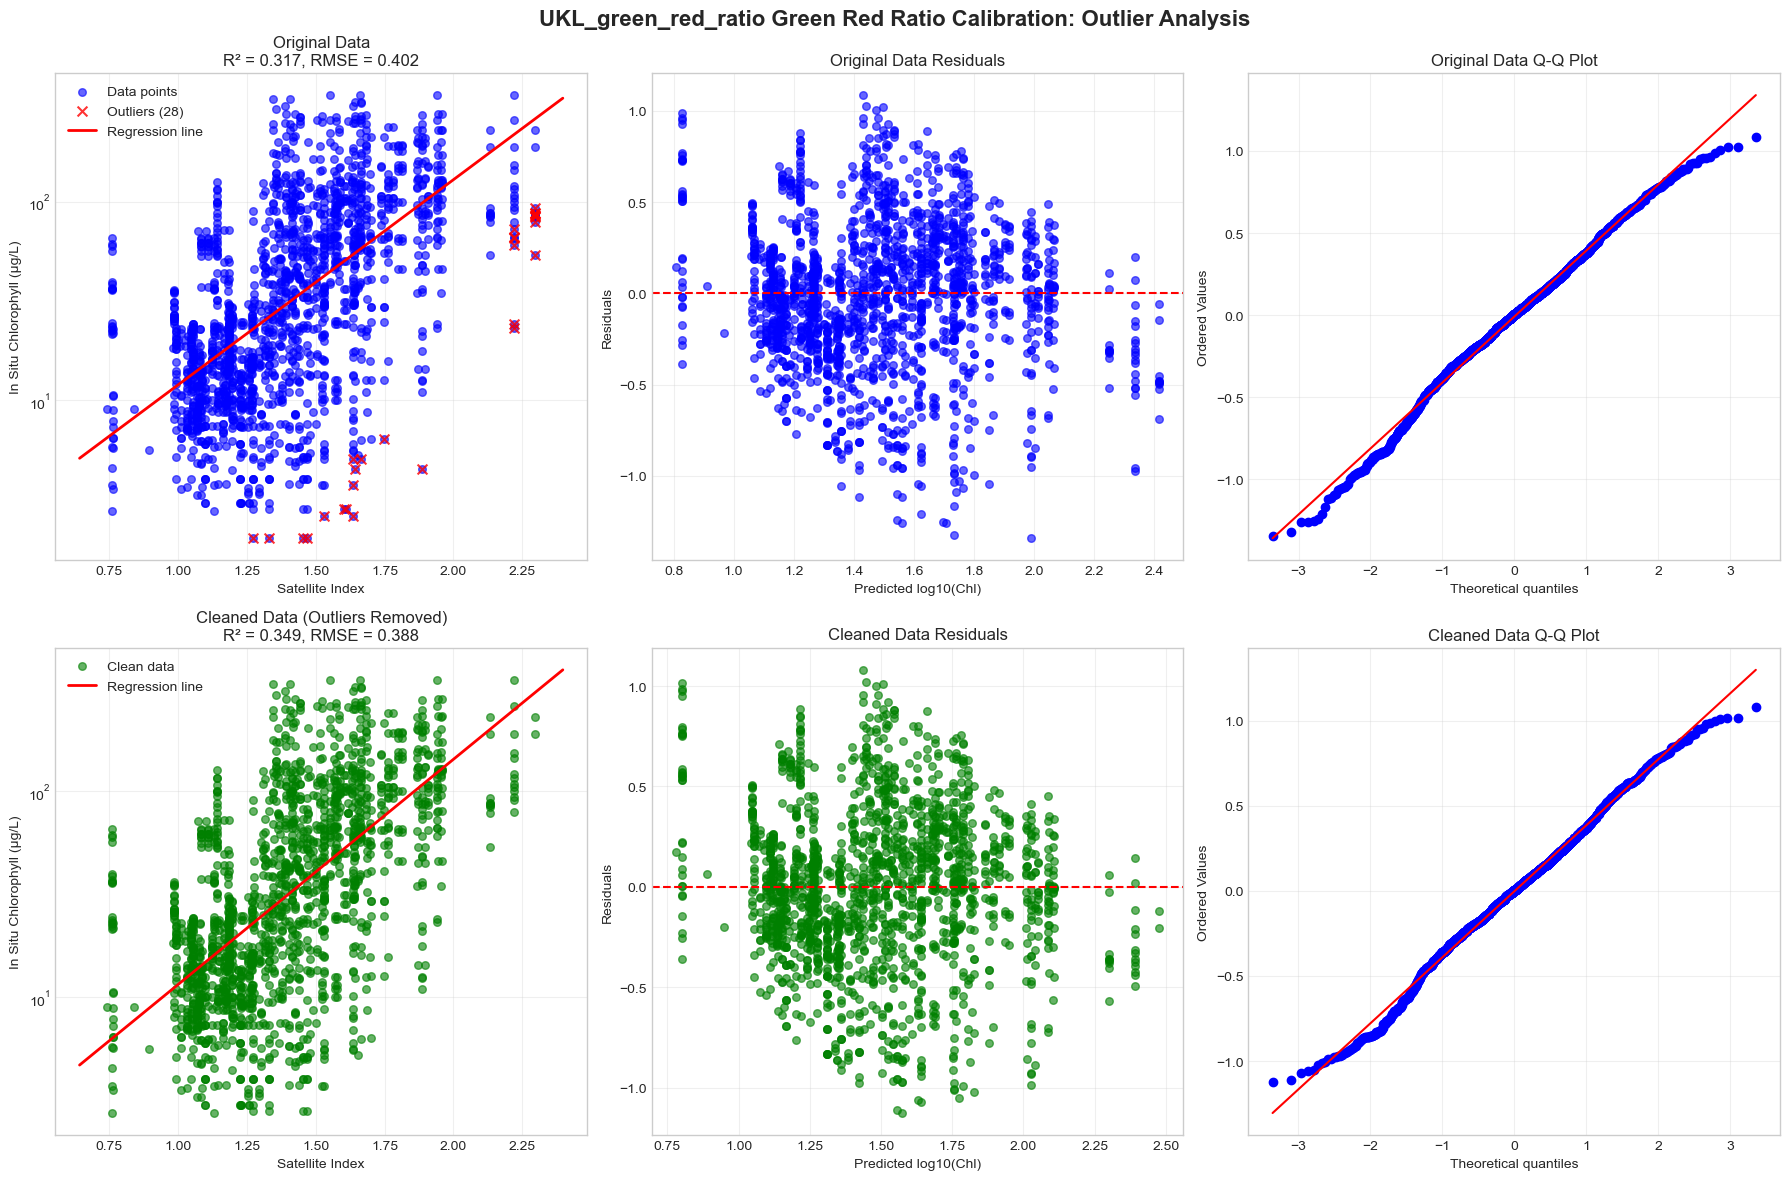

Outlier analysis plot saved: UKL_green_red_ratio_Green_Red_Ratio_outlier_analysis.png


In [6]:
# Perform calibration with outlier detection for different methods
calibration_results = {}

if 'ukl_matched_data' in locals() and len(ukl_matched_data) > 0:
    
    # Group by band ratio type for separate calibrations
    for ratio_type in ukl_matched_data['band_ratio_type'].unique():
        ratio_data = ukl_matched_data[ukl_matched_data['band_ratio_type'] == ratio_type]
        
        if len(ratio_data) >= 15:  # Need enough data for outlier detection
            print(f"\n{'='*60}")
            print(f"CALIBRATING {ratio_type.upper()} METHOD")
            print(f"{'='*60}")
            
            # Perform calibration with outlier detection
            result = calibrate_with_outlier_detection(
                ratio_data, 
                f"UKL-{ratio_type}", 
                value_col='satellite_value',
                is_log_scale=True,
                remove_outliers=True
            )
            
            if result is not None:
                calibration_results[ratio_type] = result
                
                # Create outlier analysis plot
                create_outlier_comparison_plot(
                    result, 
                    f"UKL_{ratio_type}", 
                    method_name=ratio_type.replace('_', ' ').title()
                )
        else:
            print(f"Not enough data for {ratio_type}: {len(ratio_data)} matches")
else:
    print("No matched data available for calibration")

## 5. Apply Calibrations to Full Datasets

In [7]:
# Apply calibrations to UKL data (for validation)
def apply_calibration_to_dataset(modis_data, calibration_results, dataset_name):
    """Apply calibrations to a complete dataset"""
    print(f"\nApplying calibrations to {dataset_name}...")
    
    calibrated_data = {}
    
    for sensor_name, modis_df in modis_data.items():
        if modis_df is None or len(modis_df) == 0:
            continue
            
        # Make a copy for calibration
        df_cal = modis_df.copy()
        
        # Apply different calibrations if available
        for ratio_type, cal_result in calibration_results.items():
            
            # Check if this sensor has the required ratio column
            if ratio_type in df_cal.columns:
                # Apply calibration
                df_cal = apply_calibration(
                    df_cal, 
                    ratio_type, 
                    cal_result, 
                    output_col=f'chl_{ratio_type}'
                )
                print(f"  {sensor_name} - {ratio_type}: Applied to {len(df_cal)} observations")
        
        # Store the calibrated data
        calibrated_data[sensor_name] = df_cal
    
    return calibrated_data

# Apply calibrations
if calibration_results:
    ukl_calibrated = apply_calibration_to_dataset(ukl_modis, calibration_results, "UKL")
    detroit_calibrated = apply_calibration_to_dataset(detroit_modis, calibration_results, "Detroit")
else:
    print("No calibration results available to apply")


Applying calibrations to UKL...
  UKL-Terra - green_red_ratio: Applied to 2467 observations
  UKL-Aqua - green_red_ratio: Applied to 2367 observations

Applying calibrations to Detroit...


## 6. Create Time Series Visualizations


Creating green_red_ratio time series plot for UKL...


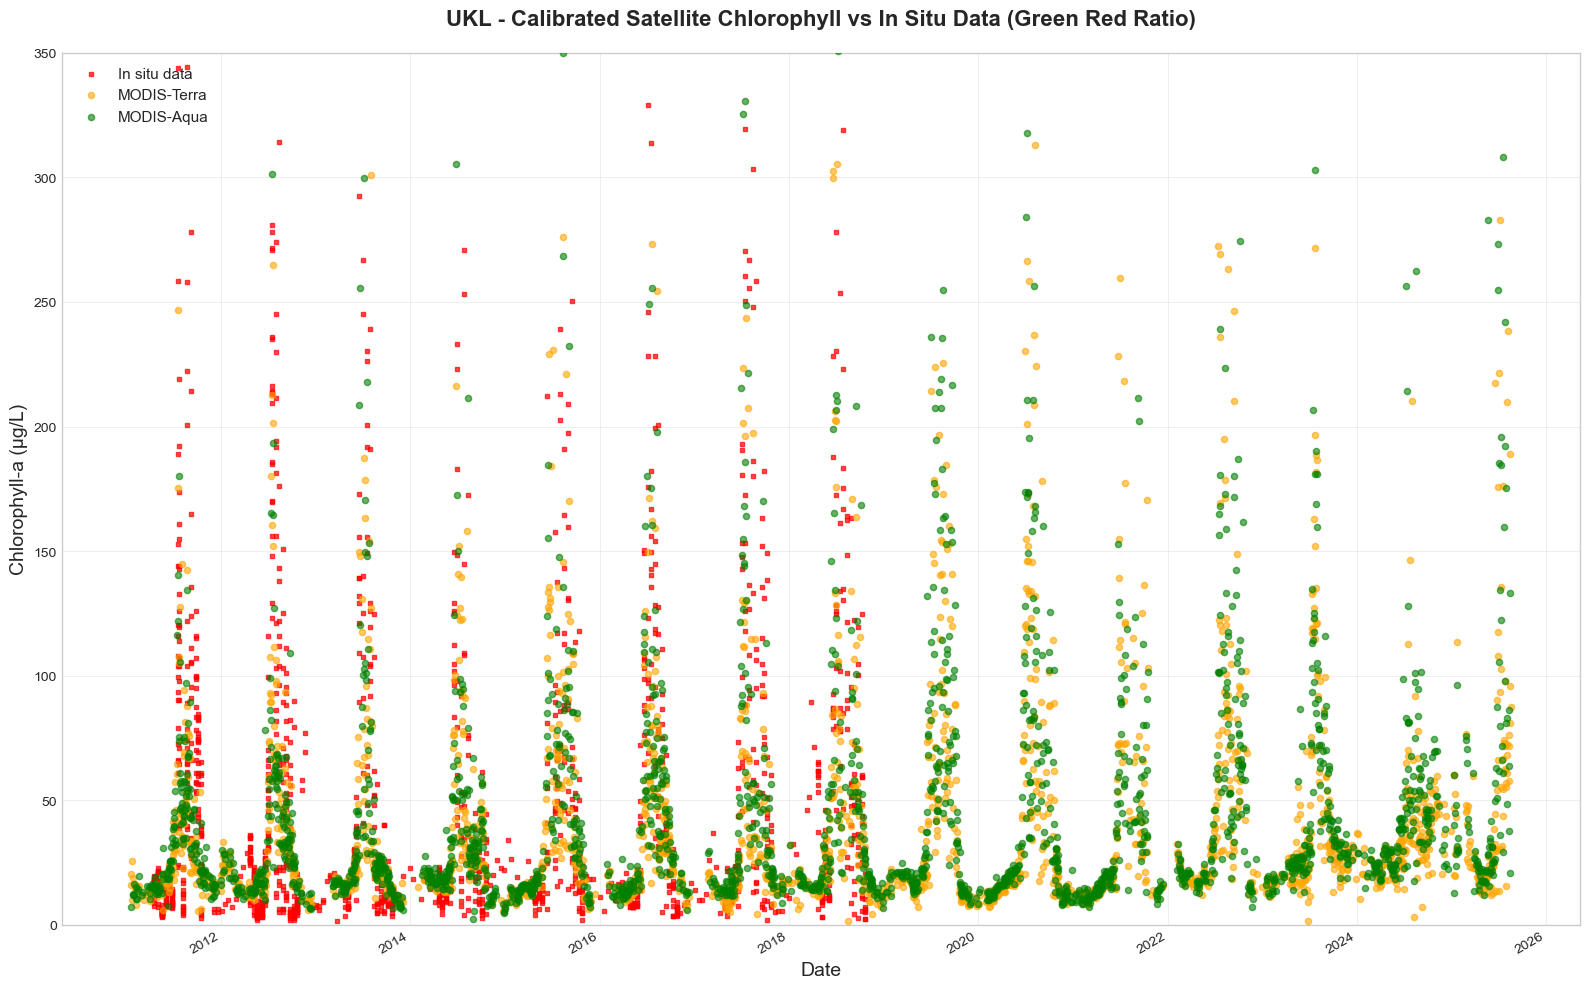

Plot saved: UKL_green_red_ratio_calibrated_time_series.png

Creating green_red_ratio time series plot for Detroit...
No data available for green_red_ratio method


In [8]:
# Create comprehensive time series plots
def create_comprehensive_time_series(calibrated_data, insitu_data, lake_name, calibration_results):
    """Create time series plots for each calibration method"""
    
    for ratio_type in calibration_results.keys():
        print(f"\nCreating {ratio_type} time series plot for {lake_name}...")
        
        # Prepare data dictionary for this method
        method_data = {}
        
        for sensor_name, df in calibrated_data.items():
            if df is not None and f'chl_{ratio_type}' in df.columns:
                # Create a clean dataset for plotting
                plot_df = df[['datetime', f'chl_{ratio_type}']].copy()
                plot_df = plot_df.rename(columns={f'chl_{ratio_type}': 'chl_calibrated'})
                plot_df = plot_df.dropna(subset=['chl_calibrated'])
                
                # Map sensor names to standard format
                if 'Terra' in sensor_name:
                    method_data['MODIS-Terra'] = plot_df
                elif 'Aqua' in sensor_name:
                    method_data['MODIS-Aqua'] = plot_df
        
        # Create the plot
        if method_data:
            method_display = ratio_type.replace('_', ' ').replace('log ', 'Log ').title()
            title = f'{lake_name} - Calibrated Satellite Chlorophyll vs In Situ Data ({method_display})'
            filename = f'{lake_name}_{ratio_type}_calibrated_time_series.png'
            
            create_time_series_plot(
                method_data,
                insitu_data,
                title,
                filename,
                lake_name
            )
        else:
            print(f"No data available for {ratio_type} method")

# Create time series plots
if 'ukl_calibrated' in locals() and calibration_results:
    create_comprehensive_time_series(ukl_calibrated, ukl_insitu, "UKL", calibration_results)
    
if 'detroit_calibrated' in locals() and calibration_results:
    create_comprehensive_time_series(detroit_calibrated, None, "Detroit", calibration_results)
else:
    print("Calibrated data not available for time series plotting")

## 7. Export Results

In [9]:
# Export calibrated data to CSV files
def export_all_results(calibrated_data, lake_name, calibration_results):
    """Export all calibration results to CSV files"""
    
    for ratio_type in calibration_results.keys():
        print(f"\nExporting {ratio_type} results for {lake_name}...")
        
        # Prepare data for export
        export_data = {}
        
        for sensor_name, df in calibrated_data.items():
            if df is not None and f'chl_{ratio_type}' in df.columns:
                # Create export dataframe
                export_df = df[['datetime', f'chl_{ratio_type}']].copy()
                export_df = export_df.rename(columns={f'chl_{ratio_type}': 'chl_calibrated'})
                export_df = export_df.dropna(subset=['chl_calibrated'])
                
                # Map sensor names
                if 'Terra' in sensor_name:
                    export_data['MODIS-Terra'] = export_df
                elif 'Aqua' in sensor_name:
                    export_data['MODIS-Aqua'] = export_df
        
        # Export using the utility function
        if export_data:
            method_name = ratio_type.replace('_', ' ').title()
            exported_files = export_calibrated_data(export_data, lake_name, method_name)
            print(f"Exported {len(exported_files)} files")

# Export results
if 'ukl_calibrated' in locals() and calibration_results:
    export_all_results(ukl_calibrated, "UKL", calibration_results)
    
if 'detroit_calibrated' in locals() and calibration_results:
    export_all_results(detroit_calibrated, "Detroit", calibration_results)
else:
    print("No calibrated data available for export")


Exporting green_red_ratio results for UKL...

Exporting UKL Green Red Ratio calibrated data to CSV files...
  Exported MODIS-Terra: 2467 records -> UKL_MODIS_Terra_Green_Red_Ratio_calibrated_chlorophyll.csv
  Exported MODIS-Aqua: 2367 records -> UKL_MODIS_Aqua_Green_Red_Ratio_calibrated_chlorophyll.csv
Exported 2 files

Exporting green_red_ratio results for Detroit...


## 8. Summary and Recommendations

In [10]:
# Print summary of results
print("\n" + "="*80)
print("ENHANCED MODIS CALIBRATION ANALYSIS - SUMMARY")
print("="*80)

if 'calibration_results' in locals() and calibration_results:
    print(f"\nCalibration Methods Processed: {len(calibration_results)}")
    
    for ratio_type, result in calibration_results.items():
        print(f"\n{ratio_type.upper()} Method:")
        print(f"  - Original R²: {result['original']['r2']:.3f}")
        print(f"  - Cleaned R²: {result['cleaned']['r2']:.3f}")
        print(f"  - RMSE: {result['cleaned']['rmse']:.3f}")
        print(f"  - Outliers removed: {result['outlier_results']['n_outliers_removed']}")
        print(f"  - Final samples: {result['cleaned']['n_matches']}")
    
    print(f"\nGenerated Outputs:")
    print(f"  - Outlier analysis plots for each method")
    print(f"  - Time series plots for UKL and Detroit")
    print(f"  - CSV files with calibrated chlorophyll data")
    
    print(f"\nRecommendations:")
    best_method = max(calibration_results.keys(), 
                     key=lambda x: calibration_results[x]['cleaned']['r2'])
    print(f"  - Best performing method: {best_method} (R² = {calibration_results[best_method]['cleaned']['r2']:.3f})")
    print(f"  - Use outlier-cleaned calibrations for final applications")
    print(f"  - Monitor predictions outside the calibration range")

else:
    print("\nNo calibration results generated.")
    print("Please check:")
    print("  - Data file paths are correct")
    print("  - Temporal matching parameters")
    print("  - Column names in input files")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


ENHANCED MODIS CALIBRATION ANALYSIS - SUMMARY

Calibration Methods Processed: 1

GREEN_RED_RATIO Method:
  - Original R²: 0.317
  - Cleaned R²: 0.349
  - RMSE: 0.388
  - Outliers removed: 28
  - Final samples: 1755

Generated Outputs:
  - Outlier analysis plots for each method
  - Time series plots for UKL and Detroit
  - CSV files with calibrated chlorophyll data

Recommendations:
  - Best performing method: green_red_ratio (R² = 0.349)
  - Use outlier-cleaned calibrations for final applications
  - Monitor predictions outside the calibration range

ANALYSIS COMPLETE!
